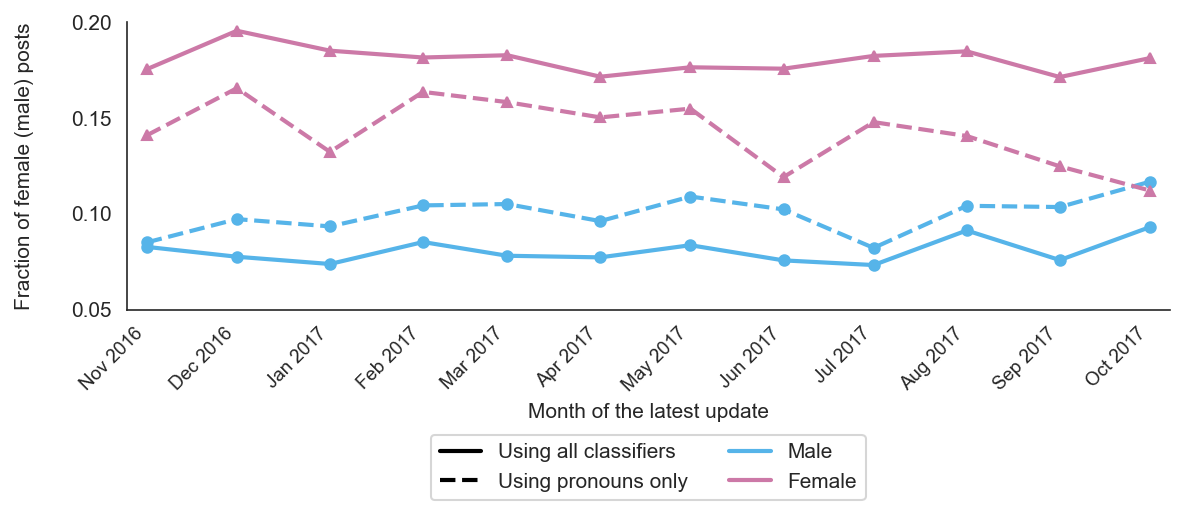

In [4]:
#####Table 1 and 2 and Figure 1 Replication#####

#Tables + Figure 1 (clean single script; only efficiency fixes)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display



vocab10K = pd.read_csv("vocab10K.csv")
trend = pd.read_csv("trend_stats.csv", parse_dates=["date"])

# --- Build Table 1 (side-by-side) ---
top_female = (
    vocab10K.sort_values("ME", ascending=False)[["word", "ME"]]
    .head(10)
    .reset_index(drop=True)
)
top_male = (
    vocab10K.sort_values("ME", ascending=True)[["word", "ME"]]
    .head(10)
    .reset_index(drop=True)
)

tab1 = pd.concat([top_female, top_male], axis=1)
tab1.columns = pd.MultiIndex.from_tuples([
    ("Most female", "Word"), ("Most female", "ME"),
    ("Most male",   "Word"), ("Most male",   "ME")
])

sty = (
    tab1.style
      .format({("Most female","ME"): "{:.3f}", ("Most male","ME"): "{:.3f}"})
      .set_caption("Table 1—Top 10 Words Most Predictive of Female/Male")
      .set_table_styles([
          {"selector": "caption", "props": [("caption-side","top"),
                                            ("font-weight","bold"),
                                            ("text-align","center"),
                                            ("margin-bottom","10px")]},
          {"selector": "th", "props": [("text-align","center"),
                                       ("border-top","2px solid black"),
                                       ("border-bottom","1px solid black")]},
          {"selector": "td", "props": [("text-align","center")]},
          {"selector": "table", "props": [("border-bottom","2px solid black"),
                                          ("margin-left","auto"),
                                          ("margin-right","auto")]}
      ])
      .hide(axis="index")
)

# ---- Table 2: Top 10 Words Most Predictive in the Pronoun Sample (A-style) ----
top_female_p = (
    vocab10K.sort_values("ME_pronoun", ascending=False)[["word", "ME_pronoun"]]
    .head(10)
    .reset_index(drop=True)
)

top_male_p = (
    vocab10K.sort_values("ME_pronoun", ascending=True)[["word", "ME_pronoun"]]
    .head(10)
    .reset_index(drop=True)
)

tab2 = pd.concat([top_female_p, top_male_p], axis=1)

# Set spanner headers like the paper
tab2.columns = pd.MultiIndex.from_tuples([
    ("Most female", "Word"), ("Most female", "ME"),
    ("Most male",   "Word"), ("Most male",   "ME")
])

# Style (same as Table 1)
sty2 = (
    tab2.style
      .format({("Most female","ME"): "{:.3f}", ("Most male","ME"): "{:.3f}"})
      .set_caption("Table 2—Top 10 Words Most Predictive (Pronoun Sample)")
      .set_table_styles([
          {"selector": "caption", "props": [
              ("caption-side","top"),
              ("font-weight","bold"),
              ("text-align","center"),
              ("margin-bottom","10px")
          ]},
          {"selector": "th", "props": [
              ("text-align","center"),
              ("border-top","2px solid black"),
              ("border-bottom","1px solid black")
          ]},
          {"selector": "td", "props": [("text-align","center")]},
          {"selector": "table", "props": [
              ("border-bottom","2px solid black"),
              ("margin-left","auto"),
              ("margin-right","auto")
          ]}
      ])
      .hide(axis="index")
)

display(sty)
display(sty2)

#######
#Figure 1

# ---- Figure 1 equivalent (match paper style) ----
sns.set_style("white")  # cleaner look like the paper

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
#fig, ax = plt.subplots(figsize=(7, 3.5), dpi=150, constrained_layout=True)

# Map female indicator to labels/colors
gender_label = {0: "Male", 1: "Female"}
gender_color = {0: "#56B4E9", 1: "#CC79A7"}  # blue, pink

# Marker mapping by gender
marker_map = {0: "o", 1: "^"}   # male = circle, female = triangle

for g in sorted(trend["female"].unique()):
    d = trend[trend["female"] == g].sort_values("date")

    ax.plot(
        d["date"], d["frac"],
        color=gender_color[g],
        linestyle="-",
        linewidth=2,
        marker=marker_map[g], markersize=5
    )

    ax.plot(
        d["date"], d["frac_pronoun"],
        color=gender_color[g],
        linestyle="--",
        linewidth=2,
        marker=marker_map[g], markersize=5
    )

# Axis formatting
ax.set_xlabel("Month of the latest update")
ax.set_ylabel("Fraction of female (male) posts", labelpad=18)
ax.set_ylim(0.05, 0.20)
ax.set_yticks([0.05, 0.10, 0.15, 0.20])

# Month ticks like "Nov 2016 ... Oct 2017"
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

ax.margins(x=0.02)                 # small padding on sides
ax.tick_params(axis='x', labelsize=9)

# Build the split legend (linestyle meaning + color meaning)
style_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Using all classifiers"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Using pronouns only"),
]
color_handles = [
    Line2D([0], [0], color=gender_color[0], lw=2, label="Male"),
    Line2D([0], [0], color=gender_color[1], lw=2, label="Female"),
]

handles = style_handles + color_handles
ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.4),
    ncol=2,
    frameon=True
)

sns.despine()
plt.tight_layout()
plt.show()
